In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
from context_flux_no.simulations.pde import CubicFlux1D
from context_flux_no.simulations.utils import generate_dataset
from context_flux_no.waveforms.grf import (
    GaussianRandomField1D,
    PeriodicCov,
)
from context_flux_no.waveforms.step import PeriodicRandomStepFunction1D

2026-05-02 15:39:33,429 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


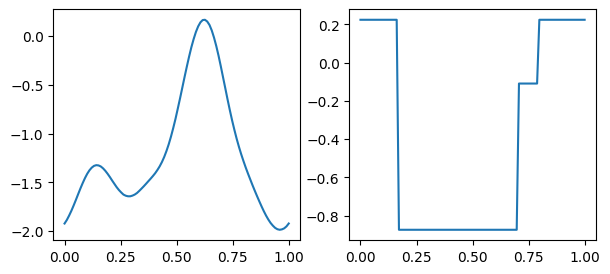

In [3]:
x = jnp.linspace(0, 1, 100)
grf = GaussianRandomField1D(PeriodicCov(corr_length=1.0))
u0 = grf.sample(x, jax.random.key(10))

step = PeriodicRandomStepFunction1D()
u0_step = step.sample(x, jax.random.key(2))
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].plot(x, u0[0])
axes[1].plot(x, u0_step[0])

In [4]:
dataset = generate_dataset(
    n_coeffs=10,
    n_ics_per_coeff=10,
    pde_factory=CubicFlux1D,
    initial_condition_fn=GaussianRandomField1D(PeriodicCov(1.0)).sample,
    coeff_range_dict={"a": (-1.0, 1.0), "b": (-1.0, 1.0), "c": (-1.0, 1.0)},
    x_span=(0, 1),
    Nx=400,
    t_span=(0, 0.5),
    Nt=100,
    seed=0,
)


100%|██████████| 10/10 [00:36<00:00,  3.61s/it]
/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/simulations/utils.py:71: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(solutions_all, "ic")  # "pde")


In [6]:
dataset

<xarray.Dataset> Size: 32MB
Dimensions:  (ic: 100, t: 101, dim: 1, x: 400, param: 3)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 12B 'u_0'
  * x        (x) float64 3kB 0.00125 0.00375 0.00625 ... 0.9938 0.9962 0.9988
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 32MB 0.04307 0.04083 ... -0.4098 -0.4112
    coeffs   (ic, param) float64 2kB -0.8828 -0.9787 -0.3249 ... -0.5787 -0.4486

In [ ]:
savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset.to_netcdf(savedir / "cubic_no_source_large_train.hdf5")

In [5]:
dataset_test = generate_dataset(
    n_coeffs=100,
    n_ics_per_coeff=10,
    pde_factory=CubicFlux1D,
    initial_condition_fn=GaussianRandomField1D(PeriodicCov(1.0)).sample,
    coeff_range_dict={"a": (-1.0, 1.0), "b": (-1.0, 1.0), "c": (-1.0, 1.0)},
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=1000,
    seed=1,
)

savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset_test.to_netcdf(savedir / "cubic_no_source_test.hdf5")

100%|██████████| 100/100 [09:11<00:00,  5.51s/it]


## Concatenate datasets into single file

In [3]:
datadir = Path("../../data")
basename = "cubic_no_source_large_train"


In [4]:
ds = xr.open_mfdataset(
    sorted(list(datadir.glob(f"{basename}_seed=*.hdf5"))),
    combine="nested",
    concat_dim="pde",
    engine="h5netcdf",
)

In [5]:
ds = ds.astype("float32", casting="same_kind")

In [6]:
ds

<xarray.Dataset> Size: 40GB
Dimensions:  (pde: 1000, ic: 100, t: 1001, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 8kB 0.0 0.0005 0.001 0.0015 ... 0.4985 0.499 0.4995 0.5
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * dim      (dim) <U1 4B 'u'
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float32 40GB dask.array<chunksize=(100, 100, 1001, 1, 100), meta=np.ndarray>
    coeffs   (pde, param) float32 12kB dask.array<chunksize=(100, 3), meta=np.ndarray>

In [7]:
ds.to_netcdf(datadir / f"{basename}.hdf5", engine="h5netcdf")